# Análise de Qualidade do Ar — Ozônio (O3) — Cidade dos EUA (2025)

**Fonte:** EPA (Environmental Protection Agency) — Daily Summary Data  
**Poluente:** Ozônio (O3) — Parâmetro 44201  
**Período:** 2025  
**Escopo:** cidade com maior número de registros no arquivo

---

**Disciplina:** 2026/1 - Introdução a Python  
**Professor:** Paulo Fernando Benetti Marcon  
**Aluno:** Leonardo da Rocha Lucena  


## O que é AQI?

O **Air Quality Index (AQI)** é um índice padronizado da EPA para comunicar a qualidade do ar.
Ele varia de **0 a 500+** e indica risco à saúde: quanto maior o valor, pior a qualidade do ar.
Nesta análise, utilizo o AQI para avaliar o comportamento do ozônio ao longo de 2025 em uma cidade específica.

| Faixa AQI | Categoria |
|-----------|-----------|
| 0 - 50 | Bom |
| 51 - 100 | Moderado |
| 101 - 150 | Não saudável (grupos sensíveis) |
| 151 - 200 | Não saudável |
| 201 - 300 | Muito não saudável |
| 301+ | Perigoso |

---

## 1. Importações e Configuração


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracoes basicas de visualizacao
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)


---
## 2. Carregamento e Tratamento dos Dados

In [54]:
# Carregar o arquivo CSV
df = pd.read_csv('daily_44201_2025.csv', low_memory=False)

print(f'Total inicial: {df.shape[0]:,} linhas x {df.shape[1]} colunas')

# Remover registros sem cidade especifica para aderir ao escopo do trabalho
df = df[df['City Name'].notna()].copy()
df = df[df['City Name'].str.strip().str.lower() != 'not in a city'].copy()

# Escolher automaticamente a cidade com mais registros
cidade_contagem = (
    df.groupby(['City Name', 'State Name'])
      .size()
      .sort_values(ascending=False)
)

cidade_escolhida, estado_escolhido = cidade_contagem.index[0]

df = df[
    (df['City Name'] == cidade_escolhida) &
    (df['State Name'] == estado_escolhido)
].copy()

print(f'Cidade analisada: {cidade_escolhida} ({estado_escolhido})')
print(f'Total apos filtro: {df.shape[0]:,} registros')
print('\nPrimeiras linhas:')
print(df.head(3))


Total inicial: 249,474 linhas x 29 colunas
Cidade analisada: Houston (Texas)
Total apos filtro: 2,873 registros

Primeiras linhas:
        State Code  County Code  Site Num  Parameter Code  POC   Latitude  \
212170          48          201        24           44201    2  29.901036   
212171          48          201        24           44201    2  29.901036   
212172          48          201        24           44201    2  29.901036   

        Longitude  Datum Parameter Name          Sample Duration  ...   AQI  \
212170 -95.326137  WGS84          Ozone  8-HR RUN AVG BEGIN HOUR  ...  31.0   
212171 -95.326137  WGS84          Ozone  8-HR RUN AVG BEGIN HOUR  ...  15.0   
212172 -95.326137  WGS84          Ozone  8-HR RUN AVG BEGIN HOUR  ...  31.0   

       Method Code                             Method Name Local Site Name  \
212170          87  INSTRUMENTAL - ULTRA VIOLET ABSORPTION  Houston Aldine   
212171          87  INSTRUMENTAL - ULTRA VIOLET ABSORPTION  Houston Aldine   
212172   

In [55]:
# Tratamento de dados

df['Date Local'] = pd.to_datetime(df['Date Local'])

# Colunas temporais para análise
df['Month'] = df['Date Local'].dt.month
df['Month Name'] = df['Month'].map({
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
})
df['Season'] = df['Month'].map({
    12: 'Inverno', 1: 'Inverno', 2: 'Inverno',
    3: 'Primavera', 4: 'Primavera', 5: 'Primavera',
    6: 'Verão', 7: 'Verão', 8: 'Verão',
    9: 'Outono', 10: 'Outono', 11: 'Outono'
})

# Classificar AQI em categorias
aqi_bins = [0, 50, 100, 150, 200, 300, 500]
aqi_labels = ['Boa', 'Moderada', 'Insalubre para grupos sensíveis', 'Insalubre', 'Muito insalubre', 'Perigosa']
df['AQI Category'] = pd.cut(df['AQI'], bins=aqi_bins, labels=aqi_labels, right=True)

# Verificar nulos nas colunas usadas
colunas_uso = ['Date Local', 'AQI', 'Month', 'Month Name', 'Season', 'AQI Category']
nulos_uso = df[colunas_uso].isnull().sum()

if nulos_uso.sum() > 0:
    print('Nulos nas colunas usadas:')
    print(nulos_uso[nulos_uso > 0])
else:
    print('Sem nulos nas colunas usadas para análise')

print(f'\nDataset pronto: {df.shape[0]:,} registros')


Sem nulos nas colunas usadas para análise

Dataset pronto: 2,873 registros


---
## 3. Exploração e Análise Estatística Descritiva

In [56]:
# Estatísticas descritivas — AQI
media_aqi = df['AQI'].mean()
mediana_aqi = df['AQI'].median()
std_aqi = df['AQI'].std()
q1, q3 = df['AQI'].quantile(0.25), df['AQI'].quantile(0.75)
iqr = q3 - q1

print('═ Estatísticas do AQI de Ozônio (O₃) ═')
print(f'Média:         {media_aqi:.2f}')
print(f'Mediana:       {mediana_aqi:.2f}')
print(f'Desvio padrão: {std_aqi:.2f}')
print(f'Mínimo:        {df["AQI"].min():.0f}')
print(f'Máximo:        {df["AQI"].max():.0f}')
print(f'Q1 (25%):      {q1:.2f}')
print(f'Q3 (75%):      {q3:.2f}')

print('\n═ Distribuição por categoria de AQI ═')
cat_counts = df['AQI Category'].value_counts().sort_index()
cat_pct = (cat_counts / len(df) * 100).round(1)
for categoria, contagem, percentual in zip(cat_counts.index.astype(str), cat_counts.values, cat_pct.values):
    print(f'{categoria:<30} {contagem:>6}  ({percentual:>5.1f}%)')


═ Estatísticas do AQI de Ozônio (O₃) ═
Média:         37.11
Mediana:       31.00
Desvio padrão: 20.49
Mínimo:        3
Máximo:        159
Q1 (25%):      23.00
Q3 (75%):      44.00

═ Distribuição por categoria de AQI ═
Boa                              2452  ( 85.3%)
Moderada                          364  ( 12.7%)
Insalubre para grupos sensíveis     55  (  1.9%)
Insalubre                           2  (  0.1%)
Muito insalubre                     0  (  0.0%)
Perigosa                            0  (  0.0%)


---
## 4. Visualizacao de Dados 

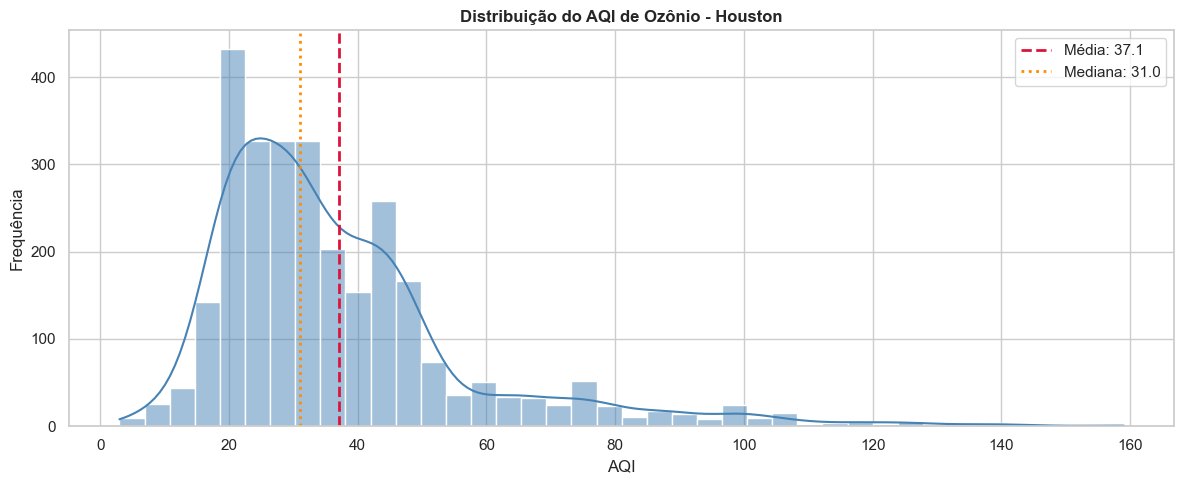

In [57]:
# Gráfico 1: Distribuição do AQI
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(data=df, x='AQI', bins=40, kde=True, color='steelblue', ax=ax)

# Linhas de referência
ax.axvline(media_aqi, color='crimson', linestyle='--', linewidth=2, label=f'Média: {media_aqi:.1f}')
ax.axvline(mediana_aqi, color='darkorange', linestyle=':', linewidth=2, label=f'Mediana: {mediana_aqi:.1f}')

ax.set_title(f'Distribuição do AQI de Ozônio - {cidade_escolhida}', fontsize=12, fontweight='bold')
ax.set_xlabel('AQI')
ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.show()


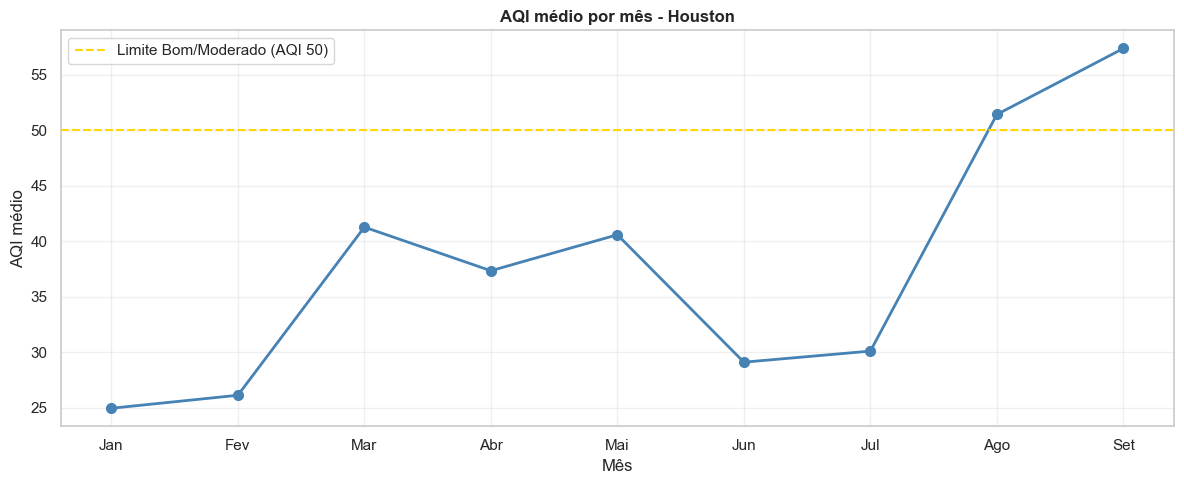

In [58]:
# Gráfico 2: AQI médio por mês (tendência)
mes_ordem = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
aqi_mensal = (
    df.groupby('Month Name')['AQI']
      .mean()
      .reindex([m for m in mes_ordem if m in df['Month Name'].unique()])
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(list(aqi_mensal.index), aqi_mensal.to_numpy(dtype=float), marker='o', color='steelblue', linewidth=2, markersize=7)
ax.axhline(50, color='gold', linestyle='--', linewidth=1.5, label='Limite Bom/Moderado (AQI 50)')

ax.set_title(f'AQI médio por mês - {cidade_escolhida}', fontsize=12, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('AQI médio')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


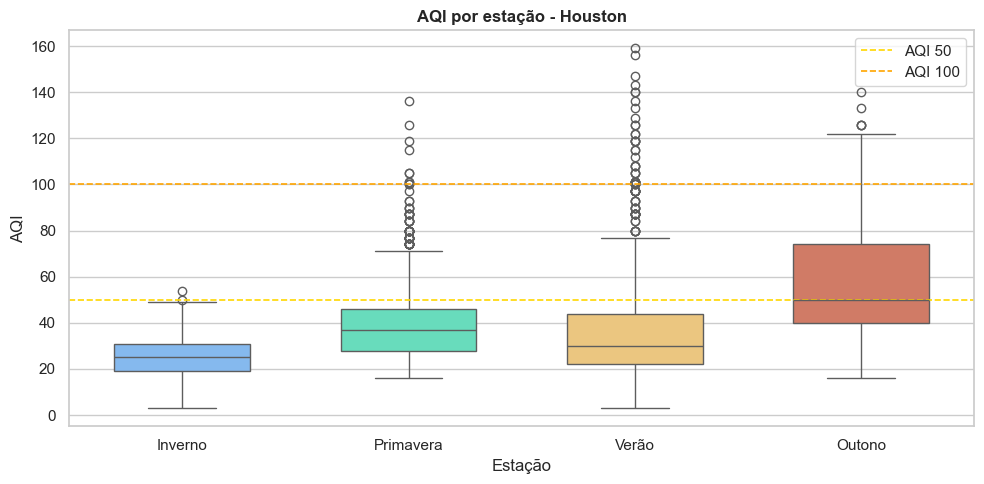

In [59]:
# Gráfico 3: Boxplot do AQI por estação
estacao_ordem = ['Inverno', 'Primavera', 'Verão', 'Outono']
estacao_cores = {'Inverno': '#74b9ff', 'Primavera': '#55efc4', 'Verão': '#fdcb6e', 'Outono': '#e17055'}

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='Season', y='AQI',
    hue='Season',
    order=estacao_ordem,
    hue_order=estacao_ordem,
    palette=estacao_cores,
    width=0.6,
    dodge=False,
    legend=False,
    ax=ax
)

ax.axhline(50, color='gold', linestyle='--', linewidth=1.2, label='AQI 50')
ax.axhline(100, color='orange', linestyle='--', linewidth=1.2, label='AQI 100')

ax.set_title(f'AQI por estação - {cidade_escolhida}', fontsize=12, fontweight='bold')
ax.set_xlabel('Estação')
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.show()


In [60]:
# Resumo analítico:

aqi_por_estacao = (
    df.groupby('Season')['AQI']
      .agg(['mean', 'median', 'max', 'count'])
      .reindex(estacao_ordem)
)

estacao_pico = aqi_por_estacao['mean'].idxmax()
mes_pico = aqi_mensal.idxmax()
mes_vale = aqi_mensal.idxmin()

pct_acima_50 = (df['AQI'] > 50).mean() * 100
pct_acima_100 = (df['AQI'] > 100).mean() * 100

print('═ Resumo analítico (cidade) ═')
print(f'Cidade analisada: {cidade_escolhida} ({estado_escolhido})')
print(f'Estação com maior AQI médio: {estacao_pico} ({aqi_por_estacao.loc[estacao_pico, "mean"]:.2f})')
print(f'Mês com maior AQI médio: {mes_pico} ({aqi_mensal.loc[mes_pico]:.2f})')
print(f'Mês com menor AQI médio: {mes_vale} ({aqi_mensal.loc[mes_vale]:.2f})')
print(f'% de dias com AQI > 50: {pct_acima_50:.2f}%')
print(f'% de dias com AQI > 100: {pct_acima_100:.2f}%')

print('\nAQI por estação:')
print(aqi_por_estacao.round(2).sort_values('mean', ascending=False))


═ Resumo analítico (cidade) ═
Cidade analisada: Houston (Texas)
Estação com maior AQI médio: Outono (57.35)
Mês com maior AQI médio: Set (57.35)
Mês com menor AQI médio: Jan (24.93)
% de dias com AQI > 50: 14.65%
% de dias com AQI > 100: 1.98%

AQI por estação:
            mean  median    max  count
Season                                
Outono     57.35    50.0  140.0    240
Primavera  39.74    37.0  136.0    998
Verão      37.04    30.0  159.0    996
Inverno    25.49    25.0   54.0    639


## 5. Interpretação dos Resultados

### Qualidade geral do ar na cidade analisada
A análise foi feita para **Houston (Texas)**, cidade com maior número de registros no arquivo de 2025.
O AQI médio foi **37.11** e a mediana **31.00**, o que sugere concentração dos valores em faixas baixas e moderadas.
Como a média ficou acima da mediana, a distribuição mostra uma leve assimetria para valores mais altos.

### Evidências quantitativas (pontos-chave)
- **Estação com maior AQI médio:** Outono (**57.35**)  
- **Mês de pico do AQI médio:** Set (**57.35**)  
- **Mês de menor AQI médio:** Jan (**24.93**)  
- **Dias com AQI > 50:** **14.65%**  
- **Dias com AQI > 100:** **1.98%**
- **Registros na categoria Bom:** **85.3%**

### Leitura analítica dos gráficos
- O histograma confirma predominância de valores baixos, com poucos registros puxando a cauda para a direita.
- A série mensal mostra aumento gradual até o fim do verão e o início do outono, quando ocorre o pico.
- O boxplot sazonal reforça que **o outono foi a estação com maior AQI médio**, acima de primavera, verão e inverno.
- O inverno apresentou os menores valores médios, o que reforça a leitura de sazonalidade do ozônio.

### Conclusão
A cidade apresenta qualidade do ar majoritariamente aceitável em 2025, mas com **sazonalidade clara** e piora no outono.
Os dados indicam que a maior parte do ano ficou em níveis baixos de AQI, mas existe um período específico de atenção entre o fim do verão e o outono.
Esse resultado fortalece a análise da disciplina porque combina limpeza de dados, estatística descritiva, comparação temporal, comparação sazonal e conclusão sustentada por evidências numéricas.

### Mapa rápido dos critérios
- **Carga e tratamento:** leitura do CSV, filtro por cidade, conversão de data e checagem de nulos.
- **Exploração e estatística:** média, mediana, desvio padrão, quartis e distribuição por categoria.
- **Visualização:** histograma, linha temporal mensal e boxplot sazonal.
- **Interpretação:** destaque para outono como maior AQI médio, mês de pico, mês de menor AQI e proporção de dias acima de 50 e 100.


---

**Fonte de dados:** EPA AQS - https://aqs.epa.gov/aqsweb/airdata/download_files.html 

**Arquivo utilizado:** [daily_44201_2025](https://aqs.epa.gov/aqsweb/airdata/daily_44201_2025.zip)
